In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [11]:
model = cv.FaceDetectorYN.create(
    "../assays/a17_deep-learning-with-opencv/face_detection_yunet_2023mar.onnx",
    "",
    (320, 320),
    0.9,
    0.3,
    5000
)

In [30]:
img = cv.imread("../../images/man.jpg")
model.setInputSize(img.shape[:2][::-1])
result = model.detect(img)

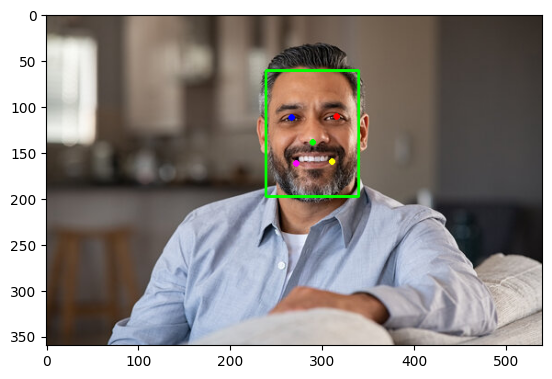

In [37]:
thickness = 2
draw_img = img.copy()
if (faces := result[1]) is not None:
    for idx, face in enumerate(faces):
        coords = face[:-1].astype(np.int32)
        cv.rectangle(draw_img, (coords[0], coords[1]), (coords[0] + coords[2], coords[1] + coords[3]), (0, 255, 0),
                     thickness)
        left_eye = (coords[4], coords[5])
        right_eye = (coords[6], coords[7])
        nose = (coords[8], coords[9])
        lip_left_corner = (coords[10], coords[11])
        lip_right_corner = (coords[12], coords[13])
        cv.circle(draw_img, left_eye, 2, (255, 0, 0), thickness)
        cv.circle(draw_img, right_eye, 2, (0, 0, 255), thickness)
        cv.circle(draw_img, nose, 2, (0, 255, 0), thickness)
        cv.circle(draw_img, lip_left_corner, 2, (255, 0, 255), thickness)
        cv.circle(draw_img, lip_right_corner, 2, (0, 255, 255), thickness)

plt.imshow(draw_img[..., ::-1])

In [42]:
%timeit model.detect(img)

6.38 ms ± 491 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
